In [171]:
print("Thinking...")
import warnings
import pandas as pd                    # For reading CSV files into tables
import numpy as np                     # For numerical calculations
print("Thinking...")
from scipy import signal               # For the Welch PSD / spectral analysis
from matplotlib import pyplot as plt   # For creating plots
import matplotlib.ticker as ticker
import os

warnings.simplefilter('ignore')

#filepath = (r"C:\Users\shrey\OneDrive\Desktop\LIGO\UtahSeisData\Seis05-clean-harb-close-noactivity-NS-along-road_2026-04-05T23-53-21-314.csv")

filepaths = []
filepaths.append(r"C:\Users\shrey\OneDrive\Desktop\LIGO\UtahSeisData\Seis07-close-i80-NS-to-i80_2026-04-06T00-32-21-479.csv")
filepaths.append(r"C:\Users\shrey\OneDrive\Desktop\LIGO\UtahSeisData\Seis10-15POLES-NS-to-i80_2026-04-06T02-21-58-225.csv")
filepaths.append(r"C:\Users\shrey\OneDrive\Desktop\LIGO\UtahSeisData\Seis08-Gypsonite-Junction-NS-I80_2026-04-06T01-41-23-216.csv")
filepaths.append(r"C:\Users\shrey\OneDrive\Desktop\LIGO\UtahSeisData\Seis05-clean-harb-close-noactivity-NS-along-road_2026-04-05T23-53-21-314.csv")
filepaths.append(r"C:\Users\shrey\OneDrive\Desktop\LIGO\UtahSeisData\Seis13-CleanHarbor-closer-NS-to-i80_2026-04-06T03-18-25-309.csv")

distances = []


distances.append(1)
distances.append(1840)
distances.append(4750)
distances.append(8220)
distances.append(9480)

avg_list_a1 = []
avg_list_a2 = []
avg_list_a3 = []
avg_list_b1 = []
avg_list_b2 = []
avg_list_b3 = []

avg_list_1 = []
avg_list_2 = []
avg_list_3 = []


for filepath in filepaths:    
    print(filepath)
    
    # Y-axis (amplitude) range in m/√Hz or m·s⁻¹/√Hz:
    y_max = 10e-5                                            # Top of the plot    (higher = more noise visible)
    y_min = 10e-14                                           # Bottom of the plot (lower = more detail at quiet levels)
    
    
    # X-axis (frequency) range in Hz:
    x_max = 100                                              # Highest frequency to show
    x_min = 0.1                                              # Lowest frequency to show
    
    
    # FFT (spectral analysis) settings:
    fft_length = 8                                           # Length of each FFT window in seconds
                                                             #   Longer = better frequency resolution, less time averaging
    
    #fft_window_s = fft_length
    
    overlap = 50                                          # Overlap between consecutive FFT windows, in percent (0–99)
    
    
    # Were the pre-amplifiers used during recording?
    pre_amps = False                                         # Set to True if pre-amps were active
    
    
    metadata = {}
    with open(filepath, 'r') as f:
        for _ in range(5):
            line = f.readline().strip()
            if ':' in line:
                key, value = line.split(':', 1)
                metadata[key.strip()] = value.strip()
    
    
    sr = float(metadata["Sample Rate"])
    #print("sr")
    #print(sr)
    
    
    # --- Read the seismic data columns ---
    raw_data = pd.read_csv(filepath, skiprows=5, delimiter=',')
    raw_data.columns = ["Sample", "Time (s)", 
                        "Noise", "East", 
                        "North", "Zed", "blank"]
    #print(raw_data.columns)
    
    
    
    if pre_amps:
        calibration = (0.0125e-1) / 21
    else:
        calibration = 0.0125e-1
    
    
    seis_Z = raw_data["Zed"] * calibration
    seis_N = raw_data["North"] * calibration
    seis_E = raw_data["East"] * calibration
    
    
    start_time = 0
    mid_time = 150
    end_time = 299
    
    start = int(start_time * sr)
    if start < 0:
        start = 0
    end = int(end_time * sr)
    mid = int(mid_time * sr)
    
    seis_Z_A = seis_Z[start:mid]
    seis_Z_B = seis_Z[mid:end]
    
    
    
    
    def welch_asd(data, sample_rate, fft_window_s, overlap):
    
        data = np.asarray(data)   # Ensure it's a plain numpy array
        
        nperseg_1  = int(sample_rate * fft_window_s)                  ## nperseg:  number of samples per FFT window
        noverlap_1 = int(round(sample_rate * (overlap * 0.01) ) )
        
        #print("nperseg:"+ str(nperseg_1))
        #print("noverlap:"+ str(noverlap_1))
    
        frequencies, power = signal.welch(
            data,
            sample_rate,
            window   = 'hamming',
            nperseg  = nperseg_1,                  ## nperseg:  number of samples per FFT window
            noverlap = noverlap_1      ## noverlap: number of samples shared between adjacent windows
        )
        
        # ASD = square root of PSD
        return frequencies, np.sqrt(power)
    
    
    def subtract_background_noise(frequencies, asd_values):
        """
        Fits a straight line below 0.8 Hz, subtracts it above 0.8 Hz,
        and returns both the corrected data and the full fitted noise line.
        """
        # Isolate the region below 0.8 Hz for fitting
        fit_mask = (frequencies < 0.8) & (frequencies > 0)
        freqs_fit = frequencies[fit_mask]
        asd_fit = asd_values[fit_mask]
        
        # Fit the line in log-log space
        slope, intercept = np.polyfit(np.log10(freqs_fit), np.log10(asd_fit), 1)
        
        # Create full noise floor curve for plotting (avoiding log10(0))
        safe_freqs = np.where(frequencies > 0, frequencies, 1e-8)
        noise_floor_full = 10**(slope * np.log10(safe_freqs) + intercept)
        
        # Correct the data above 0.8 Hz
        asd_corrected = asd_values.copy()
        sub_mask = (frequencies >= 0.8)
        
        asd_corrected[sub_mask] = np.maximum(asd_values[sub_mask] - noise_floor_full[sub_mask], 0)
        
        return asd_corrected, noise_floor_full
    
    

    #get averages for the first half of data
    frequencies_a, asd_a = welch_asd(seis_Z_A, sr, fft_length, overlap)
    asd_a_corrected, noise_line_a = subtract_background_noise(frequencies_a, asd_a)
    band1 = (frequencies_a >= 1.5) & (frequencies_a <= 3)
    band2 = (frequencies_a >= 3) & (frequencies_a <= 6)
    band3 = (frequencies_a >= 6) & (frequencies_a <= 12)
    
    average_asd_a1 = np.mean(asd_a_corrected[band1])
    avg_list_a1.append(average_asd_a1)
    average_asd_a2 = np.mean(asd_a_corrected[band2])
    avg_list_a2.append(average_asd_a2)
    average_asd_a3 = np.mean(asd_a_corrected[band3])
    avg_list_a3.append(average_asd_a3)
    
    
    #get averages for the second half of data
    frequencies_b, asd_b = welch_asd(seis_Z_B, sr, fft_length, overlap)
    asd_b_corrected, noise_line_b = subtract_background_noise(frequencies_b, asd_b)
    band1 = (frequencies_b >= 1.5) & (frequencies_b <= 3)
    band2 = (frequencies_b >= 3) & (frequencies_b <= 6)
    band3 = (frequencies_b >= 6) & (frequencies_b <= 12)
    
    average_asd_b1 = np.mean(asd_b_corrected[band1])
    avg_list_b1.append(average_asd_b1)
    average_asd_b2 = np.mean(asd_b_corrected[band2])
    avg_list_b2.append(average_asd_b2)
    average_asd_b3 = np.mean(asd_b_corrected[band3])
    avg_list_b3.append(average_asd_b3)
    

    #get averages for all of the data
    frequencies, asd = welch_asd(seis_Z, sr, fft_length, overlap)
    asd_corrected, noise_line = subtract_background_noise(frequencies, asd)
    band1 = (frequencies >= 1.5) & (frequencies <= 3)
    band2 = (frequencies >= 3) & (frequencies <= 6)
    band3 = (frequencies >= 6) & (frequencies <= 12)
    
    average_asd1 = np.mean(asd_corrected[band1])
    avg_list_1.append(average_asd1)
    average_asd2 = np.mean(asd_corrected[band2])
    avg_list_2.append(average_asd2)
    average_asd3 = np.mean(asd_corrected[band3])
    avg_list_3.append(average_asd3)


    
    
    print(f"Average ASD in 1.5-3 Hz band: {average_asd1}")
    print(f"Average ASD in 3-6 Hz band: {average_asd2}")
    print(f"Average ASD in 6-12 Hz band: {average_asd3}")

Thinking...
Thinking...
C:\Users\shrey\OneDrive\Desktop\LIGO\UtahSeisData\Seis07-close-i80-NS-to-i80_2026-04-06T00-32-21-479.csv
Average ASD in 1.5-3 Hz band: 1.932873720934796e-07
Average ASD in 3-6 Hz band: 3.590621400941299e-07
Average ASD in 6-12 Hz band: 1.0273477028263903e-06
C:\Users\shrey\OneDrive\Desktop\LIGO\UtahSeisData\Seis10-15POLES-NS-to-i80_2026-04-06T02-21-58-225.csv
Average ASD in 1.5-3 Hz band: 6.837292636423225e-08
Average ASD in 3-6 Hz band: 4.6636197787138686e-08
Average ASD in 6-12 Hz band: 2.3602600361982995e-08
C:\Users\shrey\OneDrive\Desktop\LIGO\UtahSeisData\Seis08-Gypsonite-Junction-NS-I80_2026-04-06T01-41-23-216.csv
Average ASD in 1.5-3 Hz band: 4.1027048788841866e-08
Average ASD in 3-6 Hz band: 1.875289245467787e-08
Average ASD in 6-12 Hz band: 8.929357726991448e-09
C:\Users\shrey\OneDrive\Desktop\LIGO\UtahSeisData\Seis05-clean-harb-close-noactivity-NS-along-road_2026-04-05T23-53-21-314.csv
Average ASD in 1.5-3 Hz band: 5.2754630587410824e-08
Average ASD in

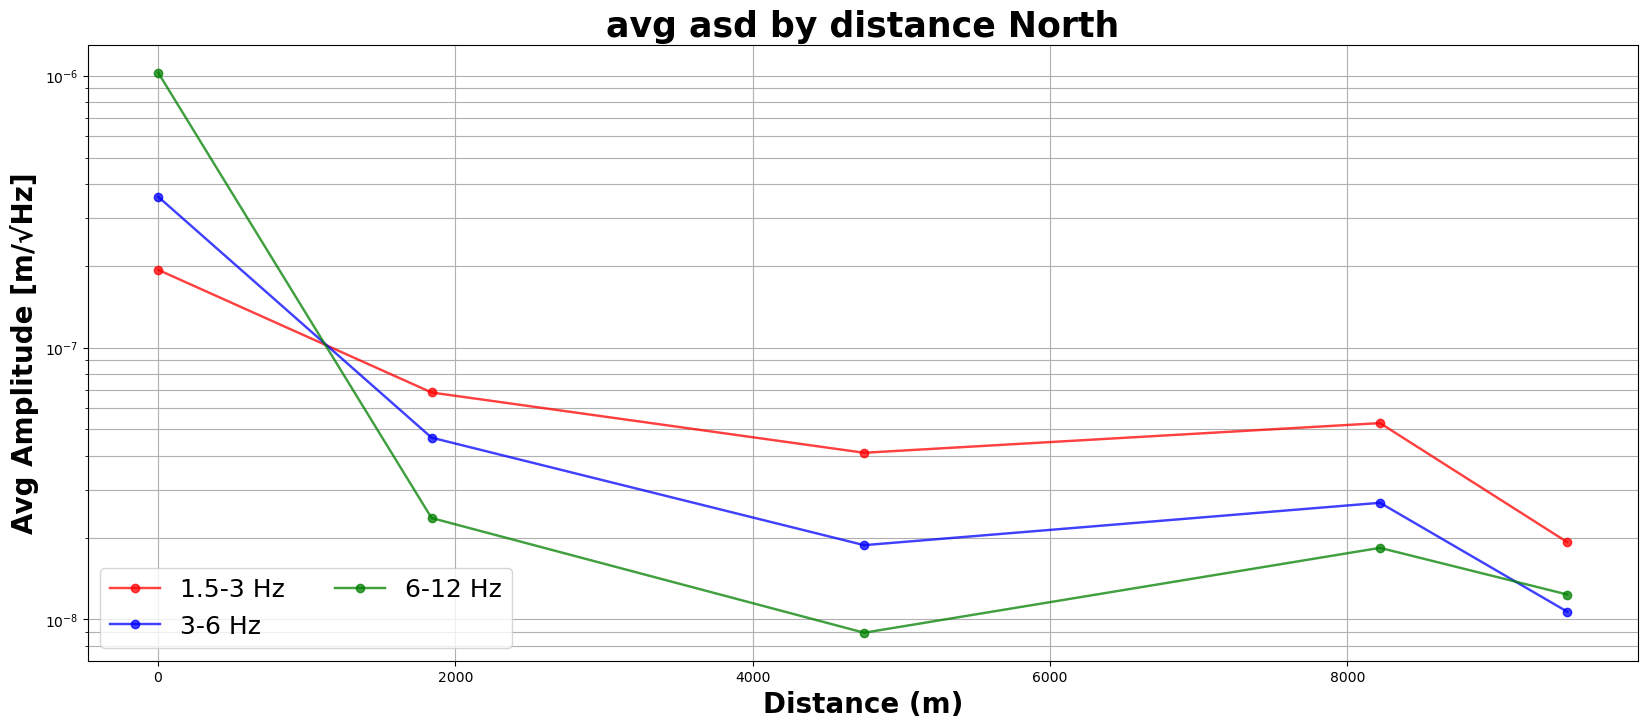

In [172]:
# Plot data

plt.figure(figsize=(20, 8))  # one figure for all files
plt.title("avg asd by distance North", fontweight='bold', fontsize=25)
plt.yscale('log')
plt.xlabel('Distance (m)', fontweight='bold', fontsize=20)
plt.ylabel('Avg Amplitude [m/√Hz]', fontweight='bold', fontsize=20)

plt.plot(distances, avg_list_1,
         color      = "red",
         linewidth  = 1.75,
         alpha      = 0.75,
         label      = "1.5-3 Hz",
         marker='o')
plt.plot(distances, avg_list_2,
         color      = "blue",
         linewidth  = 1.75,
         alpha      = 0.75,
         label      = "3-6 Hz",
         marker='o')
plt.plot(distances, avg_list_3,
         color      = "green",
         linewidth  = 1.75,
         alpha      = 0.75,
         label      = "6-12 Hz",
         marker='o')
# plt.plot(distances, avg_list_b1,
#          color      = "red",
#          linewidth  = 1.75,
#          alpha      = 0.75,
#          label      = "1.5-3 Hz",
#          marker='o')
# plt.plot(distances, avg_list_b2,
#          color      = "blue",
#          linewidth  = 1.75,
#          alpha      = 0.75,
#          label      = "3-6 Hz",
#          marker='o')
# plt.plot(distances, avg_list_b3,
#          color      = "green",
#          linewidth  = 1.75,
#          alpha      = 0.75,
#          label      = "6-12 Hz",
#          marker='o')


plt.legend(loc='lower left', fontsize=18, ncol=2)
plt.grid(True, which='both', ls='-')

In [173]:
# FIT

from scipy.optimize import curve_fit

#Function from Ground Surface Propagation model
#1/sqrt(r) with linear attenuation
def fit_func(x, a, c):
    return c*(np.sqrt(1/x))*np.exp(-a*x)

#initial guess and params
initial_guesses = [0.000001,0.0000001]
lower_bounds = [0.0,0.0]
upper_bounds = [np.inf,np.inf]

#run curve fit for first band
popt1, pcov1 = curve_fit(
    fit_func, 
    distances, 
    avg_list_1, 
    p0=initial_guesses, 
    bounds=(lower_bounds, upper_bounds),
    #sigma=avg_list_1,
    maxfev=100000
)
# Extract fitted parameters
a_fit1,c_fit1 = popt1
print(f"Fitted a: {a_fit1}")
print(f"Fitted c: {c_fit1}")

#run curve fit for second band
initial_guesses = [0.00001,0.0000001]
popt2, pcov2 = curve_fit(
    fit_func, 
    distances, 
    avg_list_2, 
    p0=initial_guesses, 
    bounds=(lower_bounds, upper_bounds),
    #sigma=avg_list_2,
    maxfev=100000
)
# Extract fitted parameters
a_fit2,c_fit2 = popt2
print(f"Fitted a: {a_fit2}")
print(f"Fitted c: {c_fit2}")


#run curve fit for 3rd band
initial_guesses = [0.00001,0.000001]
popt3, pcov3 = curve_fit(
    fit_func, 
    distances, 
    avg_list_3, 
    p0=initial_guesses, 
    bounds=(lower_bounds, upper_bounds),
    #sigma=avg_list_3,
    maxfev=100000
)
# Extract fitted parameters
a_fit3,c_fit3 = popt3
print(f"Fitted a: {a_fit3}")
print(f"Fitted c: {c_fit3}")


x_range = np.linspace(min(distances), max(distances), 100)
y_pred1 = fit_func(x_range, a_fit1,c_fit1)
y_pred2 = fit_func(x_range, a_fit2,c_fit2)
y_pred3 = fit_func(x_range, a_fit3,c_fit3)

Fitted a: 1e-10
Fitted c: 2.0000004999998747e-07
Fitted a: 1e-10
Fitted c: 4.0000014999996246e-07
Fitted a: 1e-10
Fitted c: 1.0234375001171875e-06


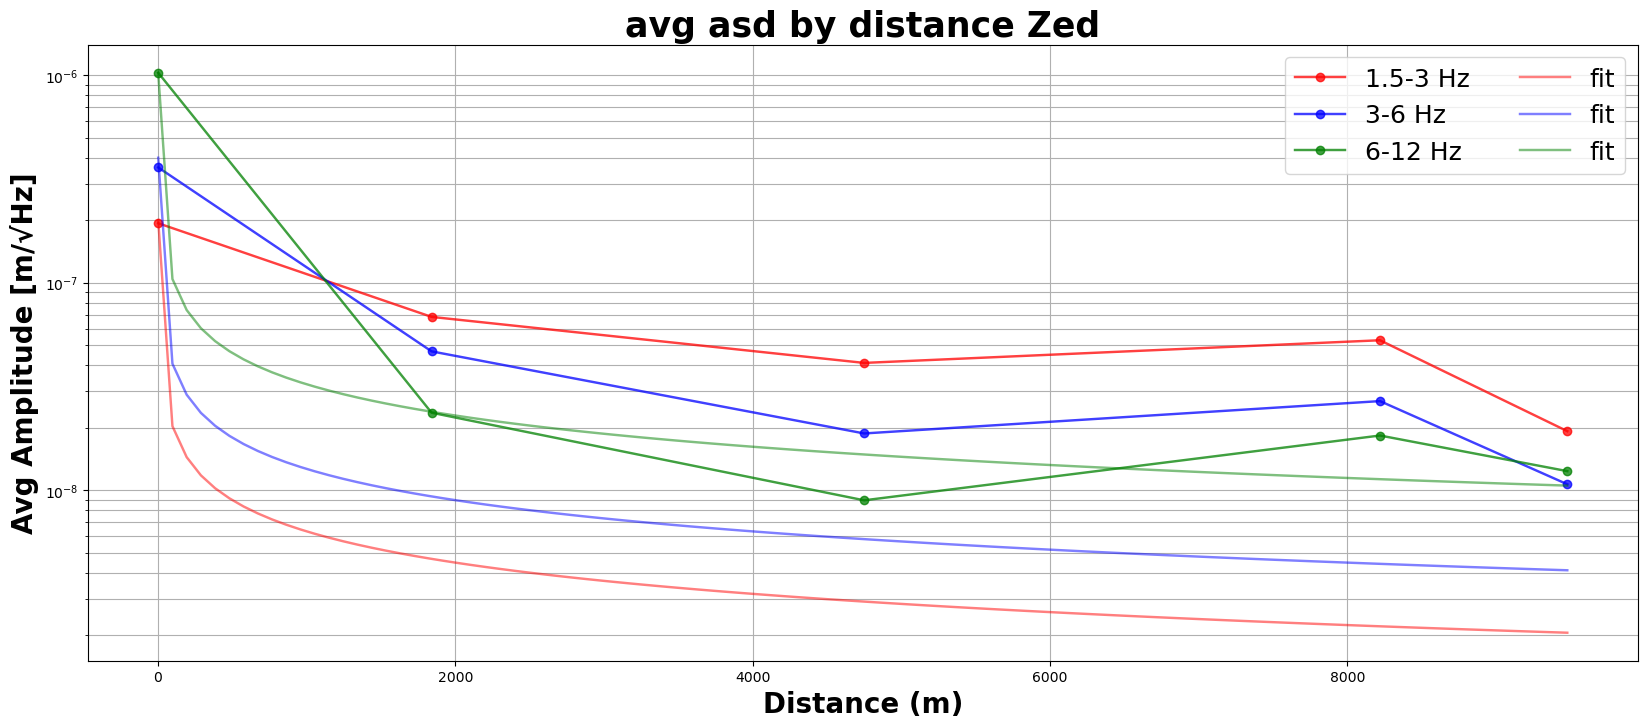

In [174]:
#plot original data with fit curves

plt.figure(figsize=(20, 8))  # one figure for all files
plt.title("avg asd by distance Zed", fontweight='bold', fontsize=25)
plt.yscale('log')
plt.xlabel('Distance (m)', fontweight='bold', fontsize=20)
plt.ylabel('Avg Amplitude [m/√Hz]', fontweight='bold', fontsize=20)

plt.plot(distances, avg_list_1,
         color      = "red",
         linewidth  = 1.75,
         alpha      = 0.75,
         label      = "1.5-3 Hz",
         marker='o')
plt.plot(distances, avg_list_2,
         color      = "blue",
         linewidth  = 1.75,
         alpha      = 0.75,
         label      = "3-6 Hz",
         marker='o')
plt.plot(distances, avg_list_3,
         color      = "green",
         linewidth  = 1.75,
         alpha      = 0.75,
         label      = "6-12 Hz",
         marker='o')

plt.plot(x_range, y_pred1,
         color      = "red",
         linewidth  = 1.75,
         alpha      = 0.5,
         label = 'fit')
         #label      = f"fit, alpha = {a_fit1:.4E}",)
plt.plot(x_range, y_pred2,
         color      = "blue",
         linewidth  = 1.75,
         alpha      = 0.5,
         label = 'fit')
         #label      = f"fit, alpha = {a_fit2:.4E}",)
plt.plot(x_range, y_pred3,
         color      = "green",
         linewidth  = 1.75,
         alpha      = 0.5,
         label = 'fit')
         #label      = f"fit, alpha = {a_fit3:.4E}",)



plt.legend(loc='upper right', fontsize=18, ncol=2)
plt.grid(True, which='both', ls='-')



In [165]:
# # FIT

# from scipy.optimize import curve_fit

# def fit_func1(x, a, c):
#     return c*(np.sqrt(1/x))*np.exp(-a*x)

# initial_guesses = [0.000001]
# lower_bounds = [0.0]
# upper_bounds = [np.inf]

# popt1, pcov1 = curve_fit(
#     fit_func1, 
#     distances, 
#     avg_list_1, 
#     p0=initial_guesses, 
#     bounds=(lower_bounds, upper_bounds),
#     sigma=avg_list_1,
#     maxfev=100000
# )
# # Extract fitted parameters
# a_fit1 = popt1
# print(f"Fitted a: {a_fit1}")
# #print(f"Fitted c: {c_fit1}")

# def fit_func2(x, a):
#     c=max(avg_list_2)
#     return c*(np.sqrt(1/x))*np.exp(-a*x)

# initial_guesses = [0.00001]
# popt2, pcov2 = curve_fit(
#     fit_func2, 
#     distances, 
#     avg_list_2, 
#     p0=initial_guesses, 
#     bounds=(lower_bounds, upper_bounds),
#     sigma=avg_list_2,
#     maxfev=100000
# )
# # Extract fitted parameters
# a_fit2 = popt2
# print(f"Fitted a: {a_fit2}")
# #print(f"Fitted c: {c_fit2}")

# def fit_func3(x, a):
#     c=max(avg_list_3)
#     return c*(np.sqrt(1/x))*np.exp(-a*x)

# initial_guesses = [0.00001]
# popt3, pcov3 = curve_fit(
#     fit_func2, 
#     distances, 
#     avg_list_3, 
#     p0=initial_guesses, 
#     bounds=(lower_bounds, upper_bounds),
#     sigma=avg_list_3,
#     maxfev=100000
# )
# # Extract fitted parameters
# a_fit3 = popt3
# print(f"Fitted a: {a_fit3}")
# #print(f"Fitted c: {c_fit3}")


# x_range = np.linspace(min(distances), max(distances), 100)
# y_pred1 = fit_func1(x_range, a_fit1)
# y_pred2 = fit_func2(x_range, a_fit2)
# y_pred3 = fit_func3(x_range, a_fit3)

In [166]:
# # --- PLOTTING SECTION ---
# plt.figure(figsize=(12, 7))

# # --- BAND A ---
# plt.loglog(frequencies_a, asd_a, label="Band A: Original ASD", color="royalblue", alpha=0.4, linestyle="--")
# plt.loglog(frequencies_a, asd_a_corrected, label=f"Band A: Corrected (Avg={average_asd_a:.2e})", color="blue", linewidth=1.5)
# # Plot the fit line specifically across its active range (from x_min up to 3Hz to avoid cluttering the high frequencies)
# viz_mask_a = (frequencies_a >= x_min) 
# plt.loglog(frequencies_a[viz_mask_a], noise_line_a[viz_mask_a], color="cyan", alpha=0.7, linestyle=":", label="Band A: Noise Fit Line")

# # --- BAND B ---
# plt.loglog(frequencies_b, asd_b, label="Band B: Original ASD", color="darkorange", alpha=0.4, linestyle="--")
# plt.loglog(frequencies_b, asd_b_corrected, label=f"Band B: Corrected (Avg={average_asd_b:.2e})", color="chocolate", linewidth=1.5)
# viz_mask_b = (frequencies_b >= x_min) 
# plt.loglog(frequencies_b[viz_mask_b], noise_line_b[viz_mask_b], color="gold", alpha=0.7, linestyle=":", label="Band B: Noise Fit Line")

# # Highlight regions for visual verification
# plt.axvspan(x_min, 0.8, color='gray', alpha=0.08, label='Noise Fit Region (< 0.8 Hz)')
# plt.axvspan(0.8, 3, color='green', alpha=0.08, label='Target Region (>0.8 Hz)')

# # Graph formatting based on your script parameters
# plt.xlim(x_min, x_max)
# plt.ylim(y_min, y_max)
# plt.xlabel("Frequency (Hz)", fontsize=12)
# plt.ylabel("ASD (m/$\sqrt{\text{Hz}}$)", fontsize=12)
# plt.title("Seismic ASD: Original Data with Background Noise Fit Subtraction", fontsize=14)
# plt.grid(True, which="both", ls="-", alpha=0.3)
# plt.legend(loc="upper right", fontsize=9, ncol=2) # 2-column legend to keep it clean

# plt.tight_layout()

# plt.show()